# NB07 — Synthesis figure

Single 4-panel summary figure combining H1 (OG enrichment categories), H2 (genome compactness/expansion), and Phase 1 clay H3 IR correction. Draft REPORT.md is produced via `/synthesize` separately.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

DATA_DIR = Path('../data')
FIG_DIR = Path('../figures'); FIG_DIR.mkdir(exist_ok=True)

enriched = pd.read_csv(DATA_DIR / 'enriched_ogs_annotated.tsv', sep='\t')
h2 = pd.read_csv(DATA_DIR / 'h2_compactness.tsv', sep='\t')
ir_corr = pd.read_csv(DATA_DIR / 'clay_h3_ir_orig_vs_corrected.tsv', sep='\t')
cohort = pd.read_csv(DATA_DIR / 'cohort_assignments.tsv', sep='\t')
presence = pd.read_parquet(DATA_DIR / 'cohort_og_presence.parquet')
n_ogs = presence.groupby('genome_id').size().reset_index(name='n_ogs')
df = cohort.merge(n_ogs, on='genome_id', how='left')
for c in ['genome_size','checkm_completeness']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df['size_rescaled'] = df['genome_size'] / (df['checkm_completeness']/100)

/tmp/ipykernel_83934/1639595038.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([anchor['size_rescaled'].dropna()/1e6, base['size_rescaled'].dropna()/1e6],


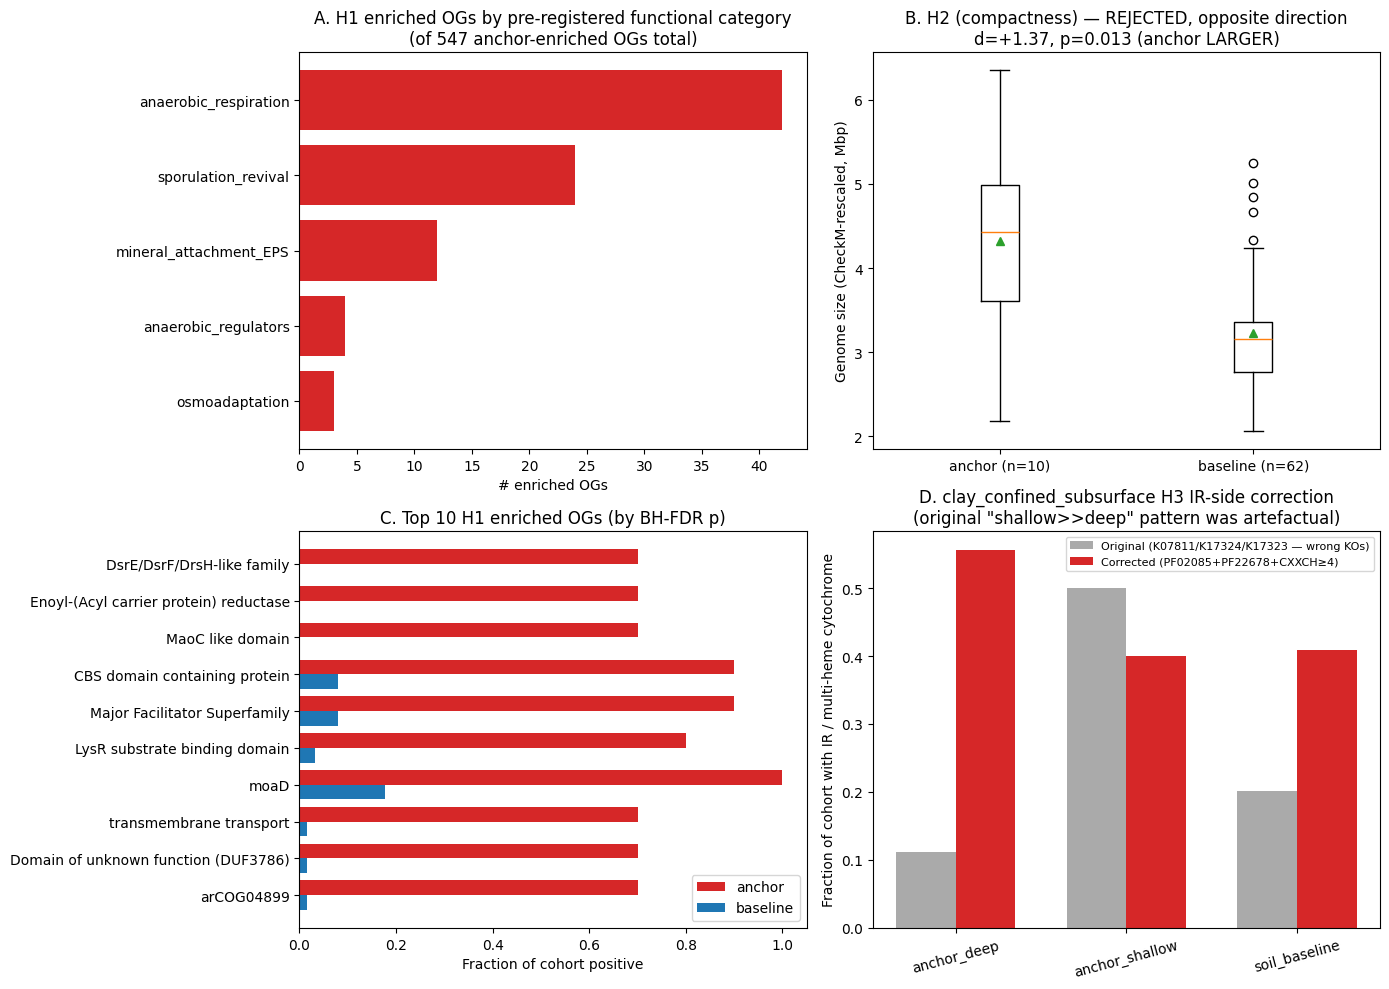

saved: ../figures/summary_figure.png


In [2]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel A — H1 pre-registered functional category breakdown (excluding 'other_or_unannotated')
ax = axes[0, 0]
cats = enriched['precategory'].value_counts()
cats = cats[cats.index != 'other_or_unannotated']
ax.barh(cats.index[::-1], cats.values[::-1], color='#d62728')
ax.set_xlabel('# enriched OGs')
ax.set_title('A. H1 enriched OGs by pre-registered functional category\n(of 547 anchor-enriched OGs total)')

# Panel B — H2 genome compactness/expansion
ax = axes[0, 1]
anchor = df[df['cohort_class']=='anchor_deep_clay']
base   = df[df['cohort_class']=='soil_baseline']
ax.boxplot([anchor['size_rescaled'].dropna()/1e6, base['size_rescaled'].dropna()/1e6],
           labels=['anchor (n=10)','baseline (n=62)'], showmeans=True)
h2_size = h2[h2['metric']=='size_rescaled'].iloc[0]
ax.set_ylabel('Genome size (CheckM-rescaled, Mbp)')
ax.set_title(f'B. H2 (compactness) — REJECTED, opposite direction\nd=+{h2_size["cohens_d"]:.2f}, p={h2_size["p"]:.3f} (anchor LARGER)')

# Panel C — top 10 H1 enriched OGs by p_BH (forest)
ax = axes[1, 0]
top = enriched.head(10).copy()
def lbl(r):
    for k in ['preferred_name','description','og_id']:
        v = r.get(k)
        if v is not None and isinstance(v, str) and v.strip():
            return v[:40]
    return r.get('og_id','?')[:40]
top['label'] = top.apply(lbl, axis=1)
y = np.arange(len(top))[::-1]
ax.barh(y, top['rate_anchor'], 0.4, label='anchor', color='#d62728')
ax.barh(y - 0.4, top['rate_base'], 0.4, label='baseline', color='#1f77b4')
ax.set_yticks(y - 0.2)
ax.set_yticklabels(top['label'].tolist())
ax.set_xlabel('Fraction of cohort positive')
ax.set_title('C. Top 10 H1 enriched OGs (by BH-FDR p)')
ax.legend(loc='lower right')

# Panel D — Phase 1 clay H3 IR correction
ax = axes[1, 1]
order = ['anchor_deep', 'anchor_shallow', 'soil_baseline']
ir_plot = ir_corr.set_index('cohort_class').reindex(order)
x = np.arange(len(order)); w = 0.35
ax.bar(x - w/2, ir_plot['IR_complete_original_rate'].values, w,
       label='Original (K07811/K17324/K17323 — wrong KOs)', color='#aaaaaa')
ax.bar(x + w/2, ir_plot['has_multiheme_cyt_corrected_rate'].values, w,
       label='Corrected (PF02085+PF22678+CXXCH≥4)', color='#d62728')
ax.set_xticks(x); ax.set_xticklabels(order, rotation=15)
ax.set_ylabel('Fraction of cohort with IR / multi-heme cytochrome')
ax.set_title('D. clay_confined_subsurface H3 IR-side correction\n(original "shallow>>deep" pattern was artefactual)')
ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
out_fig = FIG_DIR / 'summary_figure.png'
plt.savefig(out_fig, dpi=140, bbox_inches='tight')
plt.show()
print(f'saved: {out_fig}')